<a href="https://colab.research.google.com/github/Abdul-RahmanAI/urdu-ocr-codesaviours-si26--AbdulRahman-/blob/main/SI26_Week2_%5BAbdulRahman%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Urdu OCR Project
The purpose of this notebook is to prepare the Urdu OCR dataset for training. It includes loading the dataset, preprocessing the images, creating labels, and performing the tasks required for Week 2.


In [7]:
# Install required libraries
!pip install opencv-python-headless pillow

# Import libraries
import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [8]:
from google.colab import files

uploaded = files.upload()

Saving urdu_ocr_data.rar to urdu_ocr_data.rar


In [9]:
import os

print(os.listdir("/content"))

['.config', 'data', 'urdu_ocr_data.rar', 'sample_data']


In [10]:
!apt-get update -qq
!apt-get install -y unrar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 91 not upgraded.


In [11]:
!unrar x "/content/urdu_ocr_data.rar" "/content/urdu_ocr_data/"

Streaming output truncated to the last 5000 lines.
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/55.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/550.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5500.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5501.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5502.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5503.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5504.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5505.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undegraded/5506.png      52%  OK 
Extracting  /content/urdu_ocr_data/line_undegraded/line_undeg

In [12]:
import os

print(os.listdir("/content/urdu_ocr_data"))

['line_undegraded', 'realgt']


In [13]:
import os

print(os.listdir("/content/urdu_ocr_data/line_undegraded"))

['line_undegraded']


In [14]:
import os

print(os.listdir("/content/urdu_ocr_data/line_undegraded/line_undegraded")[:10])

['6058.png', '2641.png', '2052.png', '5706.png', '446.png', '5597.png', '5661.png', '267.png', '9126.png', '802.png']


In [15]:
def preprocess_image(image_path, save_path):
    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f'Could not load: {image_path}')
        return

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to a standard size
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Step 4: Convert to black and white
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    # Save the processed image
    cv2.imwrite(save_path, binary)

    return binary


# Create output folder
os.makedirs('data/processed', exist_ok=True)

print('Preprocessing function is ready!')

Preprocessing function is ready!


In [16]:
import glob
import os
import cv2


def preprocess_image(image_path, save_path):
    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return None

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard size
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Fast noise removal
    denoised = cv2.GaussianBlur(resized, (3, 3), 0)

    # Step 4: Convert to black & white (automatic threshold)
    _, binary = cv2.threshold(
        denoised,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Save processed image
    cv2.imwrite(save_path, binary)

    return binary

os.makedirs("data/processed", exist_ok=True)


dataset_path = "/content/urdu_ocr_data/line_undegraded/line_undegraded"

# Find all PNG images
all_images = glob.glob(os.path.join(dataset_path, "*.png"))

print(f"Found {len(all_images)} images to process")

processed_count = 0

for i, img_path in enumerate(all_images):

    filename = os.path.basename(img_path)

    save_path = os.path.join("data/processed", filename)

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed_count += 1

    # Show progress every 500 images
    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1} images...")

print(f"Done! Processed {processed_count} images")
print("Processed images are saved in: data/processed/")


Found 10063 images to process
Processed 500 images...
Processed 1000 images...
Processed 1500 images...
Processed 2000 images...
Processed 2500 images...
Processed 3000 images...
Processed 3500 images...
Processed 4000 images...
Processed 4500 images...
Processed 5000 images...
Processed 5500 images...
Processed 6000 images...
Processed 6500 images...
Processed 7000 images...
Processed 7500 images...
Processed 8000 images...
Processed 8500 images...
Processed 9000 images...
Processed 9500 images...
Processed 10000 images...
Done! Processed 10063 images
Processed images are saved in: data/processed/


In [18]:
# Install Tesseract OCR and Urdu language pack
!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-urd

# Install Python wrapper
!pip install pytesseract

# Import libraries
import pytesseract
from PIL import Image
import glob
import os

# Find 5 processed images
test_images = sorted(glob.glob("data/processed/*.png"))[:5]

print("========== Tesseract Results on Urdu Images ==========\n")

for img_path in test_images:

    # Open image
    img = Image.open(img_path)

    # Perform OCR using Urdu language
    result = pytesseract.image_to_string(img, lang="urd")

    print(f"Image: {os.path.basename(img_path)}")
    print("Tesseract Output:")
    print(result.strip())
    print("-" * 50)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-urd is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 91 not upgraded.
========== Tesseract Results on Urdu Images ==========

Image: 0.png
Tesseract Output:
ای کر ٹیر
--------------------------------------------------
Image: 1.png
Tesseract Output:
لم و ملا ےار ابی
--------------------------------------------------
Image: 10.png
Tesseract Output:
نک وک وک و
--------------------------------------------------
Image: 100.png
Tesseract Output:
راف کیب اما ٤ہ‏
--------------------------------------------------
Image: 1000.png
Tesseract Output:
ےد او اہم ان ےک
--------------------

#Gap Analysis

The purpose of this analysis is to compare the OCR output generated by Tesseract with the actual Urdu text present in the dataset. This comparison helps identify the limitations of Tesseract OCR for Urdu text recognition.

## Image 0.png

### Actual Urdu Text
*(.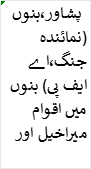)*

### Tesseract Output
```
ای کر ٹیر
```

### Analysis
- The extracted text does not match the original Urdu sentence.
- Several Urdu characters were recognized incorrectly.
- Some words are missing from the output.
- The extracted text does not preserve the original meaning.

## Image 1.png

### Actual Urdu Text
*(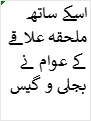)*

### Tesseract Output
```
لم و ملا ےار ابی
```

### Analysis
- Tesseract recognized several characters incorrectly.
- Some Urdu words are incomplete.
- The sentence structure is broken.
- The OCR output is not an accurate representation of the original text.

## Image 10.png

### Actual Urdu Text
*(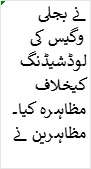)*

### Tesseract Output
```
نک وک وک و
```

### Analysis
- Most of the original words were not recognized.
- The extracted text is incomplete.
- The OCR result contains meaningless words.
- Recognition accuracy is very poor.

## Image 100.png

### Actual Urdu Text
*(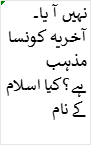)*

### Tesseract Output
```
راف کیب اما ٤ہ‏
```

### Analysis
- Several Urdu characters are recognized incorrectly.
- Some words are missing completely.
- The extracted sentence differs significantly from the original text.
- OCR performance is unsatisfactory.

## Image 1000.png

### Actual Urdu Text
*(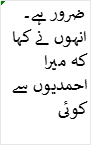)*

### Tesseract Output
```
ےد او اہم ان ےک
```

### Analysis
- The extracted text contains incorrect characters.
- Multiple words are missing.
- The output is incomplete and difficult to understand.
- Tesseract failed to accurately recognize the Urdu sentence.

# Summary

## Reason for Why Tesseract Fails on Urdu

Tesseract fails on Urdu because it struggles to recognize the complex structure of the Urdu writing system. Urdu contains connected characters, ligatures, different writing styles, varying fonts, and image quality variations. During testing, Tesseract produced incorrect characters, missing words, incomplete sentences, and meaningless text for several images. These results clearly demonstrate that Tesseract is not sufficiently accurate for this dataset. Therefore, a custom OCR model trained specifically on this Urdu dataset is required to achieve higher recognition accuracy and better overall performance.

# Conclusion

This experiment demonstrates the limitations of using a general-purpose OCR engine such as Tesseract for Urdu text recognition. Although Tesseract provides basic support for the Urdu language, its performance on this dataset is not satisfactory. Building and training a custom deep learning OCR model on this dataset is expected to significantly improve recognition accuracy and produce more reliable results.